# Figure S4. UHGV high-confidence filters

In [44]:
### Load packages
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

In [45]:
import polars as pl

### Load final sequences in UHVDB
seqhasher = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t')

In [46]:
import polars as pl

### Load classify outputs
uhgv_hq_hc_classify = pl.read_csv('../figure_1/uhgv_hq_hc_results/2026-03-23_outputs/classify/new_mq_plus_classify.tsv.gz', separator='\t', columns=['seq_name', 'virus_score', 'n_hallmarks', 'plasmid_hallmarks', 'uhvdb_virus_classification', 'completeness_method']).filter(pl.col('uhvdb_virus_classification') != 'non-viral')
uhgv_hq_lc_classify = pl.read_csv('../figure_1/uhgv_hq_lc_results/2026-03-25_outputs/classify/new_mq_plus_classify.tsv.gz', separator='\t', columns=['seq_name', 'virus_score', 'n_hallmarks', 'plasmid_hallmarks', 'uhvdb_virus_classification', 'completeness_method']).filter(pl.col('uhvdb_virus_classification') != 'non-viral')
uhvdb_virusdb_classify = pl.read_csv('../figure_1/uhvdb_virus_db_results/2026-03-26_outputs/classify/new_mq_plus_classify.tsv.gz', separator='\t', columns=['seq_name', 'virus_score', 'n_hallmarks', 'plasmid_hallmarks', 'uhvdb_virus_classification', 'completeness_method']).filter(pl.col('uhvdb_virus_classification') != 'non-viral')
uhvdb_metag_classify = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/classify/new_mq_plus_classify.tsv.gz', separator='\t', columns=['seq_name', 'virus_score', 'n_hallmarks', 'plasmid_hallmarks', 'uhvdb_virus_classification', 'completeness_method']).filter(pl.col('uhvdb_virus_classification') != 'non-viral')

dtr_seqs = (
    set(uhgv_hq_hc_classify.filter(pl.col('completeness_method').str.contains('DTR'))['seq_name'])
    .union(set(uhgv_hq_lc_classify.filter(pl.col('completeness_method').str.contains('DTR'))['seq_name']))
    .union(set(uhvdb_virusdb_classify.filter(pl.col('completeness_method').str.contains('DTR'))['seq_name']))
    .union(set(uhvdb_metag_classify.filter(pl.col('completeness_method').str.contains('DTR'))['seq_name']))
)

In [47]:
### Load HQfilter outputs
uhgv_hq_hc_hqfilter = set(pl.read_csv('../figure_1/uhgv_hq_hc_results/2026-03-23_outputs/hqfilter/new_hqfilter.tsv.gz', separator='\t').filter((pl.col('aai_completeness') >= 90) | ((pl.col('contig_id').is_in(dtr_seqs)) & (pl.col('aai_completeness') >= 80)))['contig_id'])
uhgv_hq_lc_hqfilter = set(pl.read_csv('../figure_1/uhgv_hq_lc_results/2026-03-25_outputs/hqfilter/new_hqfilter.tsv.gz', separator='\t').filter((pl.col('aai_completeness') >= 90) | ((pl.col('contig_id').is_in(dtr_seqs)) & (pl.col('aai_completeness') >= 80)))['contig_id'])
uhvdb_virusdb_hqfilter = set(pl.read_csv('../figure_1/uhvdb_virus_db_results/2026-03-26_outputs/hqfilter/new_hqfilter.tsv.gz', separator='\t', ignore_errors=True).filter((pl.col('aai_completeness') >= 90) | ((pl.col('contig_id').is_in(dtr_seqs)) & (pl.col('aai_completeness') >= 80)))['contig_id'])
uhvdb_metag_hqfilter = set(pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/hqfilter/new_hqfilter.tsv.gz', separator='\t', ignore_errors=True).filter((pl.col('aai_completeness') >= 90) | ((pl.col('contig_id').is_in(dtr_seqs)) & (pl.col('aai_completeness') >= 80)))['contig_id'])

print(f"Number of HQ viruses in all datasets: {len(uhgv_hq_hc_hqfilter) + len(uhgv_hq_lc_hqfilter) + len(uhvdb_virusdb_hqfilter) + len(uhvdb_metag_hqfilter)}")

Number of HQ viruses in all datasets: 771028


In [48]:
print("Number of HQ uncertain viruses:",
    uhgv_hq_hc_classify.filter((pl.col('seq_name').is_in(uhgv_hq_hc_hqfilter)) & (pl.col('uhvdb_virus_classification') == 'uncertain')).unique('seq_name').height +
    uhgv_hq_lc_classify.filter((pl.col('seq_name').is_in(uhgv_hq_lc_hqfilter)) & (pl.col('uhvdb_virus_classification') == 'uncertain')).unique('seq_name').height +
    uhvdb_virusdb_classify.filter((pl.col('seq_name').is_in(uhvdb_virusdb_hqfilter)) & (pl.col('uhvdb_virus_classification') == 'uncertain')).unique('seq_name').height +
    uhvdb_metag_classify.filter((pl.col('seq_name').is_in(uhvdb_metag_hqfilter)) & (pl.col('uhvdb_virus_classification') == 'uncertain')).unique('seq_name').height
)

Number of HQ uncertain viruses: 20331


In [49]:
print("Number of HQ confident viruses:",
    uhgv_hq_hc_classify.filter((pl.col('seq_name').is_in(uhgv_hq_hc_hqfilter)) & (pl.col('uhvdb_virus_classification') == 'confident')).unique('seq_name').height +
    uhgv_hq_lc_classify.filter((pl.col('seq_name').is_in(uhgv_hq_lc_hqfilter)) & (pl.col('uhvdb_virus_classification') == 'confident')).unique('seq_name').height +
    uhvdb_virusdb_classify.filter((pl.col('seq_name').is_in(uhvdb_virusdb_hqfilter)) & (pl.col('uhvdb_virus_classification') == 'confident')).unique('seq_name').height +
    uhvdb_metag_classify.filter((pl.col('seq_name').is_in(uhvdb_metag_hqfilter)) & (pl.col('uhvdb_virus_classification') == 'confident')).unique('seq_name').height
)

Number of HQ confident viruses: 750697


In [50]:
### Identify number of uncertain viruses included in UHVDB
print("Number of uncertain viruses re-classified as confident:",
    len(
        set(uhgv_hq_hc_classify.filter((pl.col('seq_name').is_in(uhgv_hq_hc_hqfilter)) & (pl.col('uhvdb_virus_classification') == 'uncertain'))['seq_name'])
        .union(set(uhgv_hq_lc_classify.filter((pl.col('seq_name').is_in(uhgv_hq_lc_hqfilter)) & (pl.col('uhvdb_virus_classification') == 'uncertain'))['seq_name']))
        .union(set(uhvdb_virusdb_classify.filter((pl.col('seq_name').is_in(uhvdb_virusdb_hqfilter)) & (pl.col('uhvdb_virus_classification') == 'uncertain'))['seq_name']))
        .union(set(uhvdb_metag_classify.filter((pl.col('seq_name').is_in(uhvdb_metag_hqfilter)) & (pl.col('uhvdb_virus_classification') == 'uncertain'))['seq_name']))
        .intersection(set(seqhasher['original_id']))
    )
)

Number of uncertain viruses re-classified as confident: 9960


(0.0, 100.0)

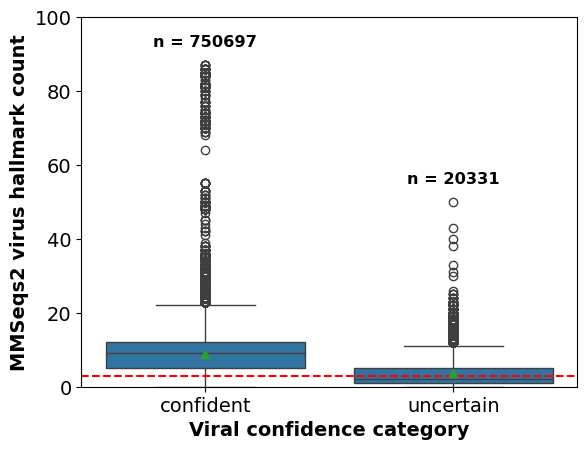

In [51]:
### Plot number of MMSEeqs2 virus hallmarks in UHVDB HQ+ dereplicated genomes
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

combined_df = (
    pl.concat([
        uhgv_hq_hc_classify.filter(pl.col('seq_name').is_in(uhgv_hq_hc_hqfilter)),
        uhgv_hq_lc_classify.filter(pl.col('seq_name').is_in(uhgv_hq_lc_hqfilter)),
        uhvdb_virusdb_classify.filter(pl.col('seq_name').is_in(uhvdb_virusdb_hqfilter)),
        uhvdb_metag_classify.filter(pl.col('seq_name').is_in(uhvdb_metag_hqfilter))
    ])
    .unique('seq_name')
)
ax = sns.boxplot(data=combined_df, x="uhvdb_virus_classification", y="n_hallmarks", showmeans=True)
plt.ylabel("MMSeqs2 virus hallmark count", fontdict={'fontweight': 'bold'})
plt.xlabel("Viral confidence category", fontdict={'fontweight': 'bold'})
plt.axhline(3, color='r', linestyle='dashed')

maxes = combined_df.group_by(['uhvdb_virus_classification']).agg([pl.col('n_hallmarks').max()]).sort('uhvdb_virus_classification')['n_hallmarks']
nobs = combined_df['uhvdb_virus_classification'].value_counts().sort('uhvdb_virus_classification')['count']

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],
            maxes[tick] + 5,
            "n = " + str(nobs[tick]),
            horizontalalignment='center',
            size='small',
            color='black',
            weight='semibold')

plt.ylim(0, 100)

(0.0, 55.0)

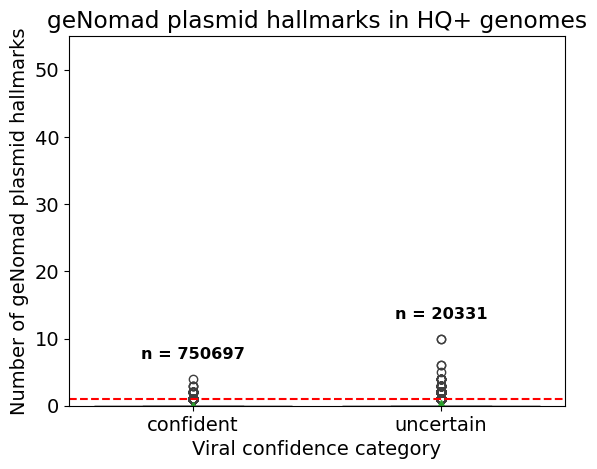

In [52]:
### Plot number of MMSEeqs2 plasmid hallmarks in UHVDB HQ+ dereplicated genomes
ax = sns.boxplot(data=combined_df, x="uhvdb_virus_classification", y="plasmid_hallmarks", showmeans=True)
plt.title("geNomad plasmid hallmarks in HQ+ genomes")
plt.ylabel("Number of geNomad plasmid hallmarks")
plt.xlabel("Viral confidence category")
plt.axhline(1, color='r', linestyle='dashed')

maxes = combined_df.group_by(['uhvdb_virus_classification']).agg([pl.col('plasmid_hallmarks').max()]).sort('uhvdb_virus_classification')['plasmid_hallmarks']
nobs = combined_df['uhvdb_virus_classification'].value_counts().sort('uhvdb_virus_classification')['count']

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],
            maxes[tick] + 3,
            "n = " + str(nobs[tick]),
            horizontalalignment='center',
            size='small',
            color='black',
            weight='semibold')

plt.ylim(0, 55)

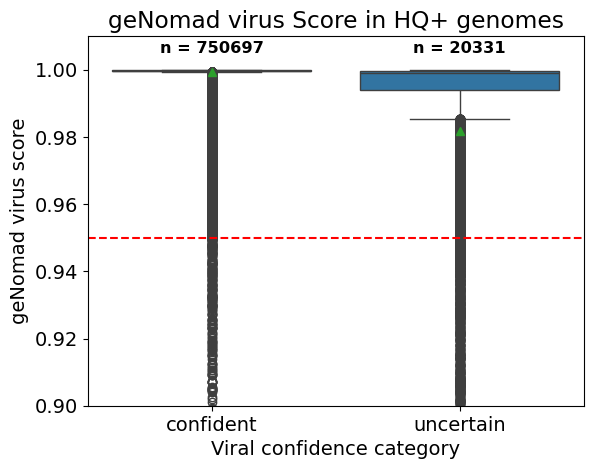

In [53]:
### Plot geNomad virus score in UHVDB HQ+ dereplicated genomes
ax = sns.boxplot(data=combined_df, x="uhvdb_virus_classification", y="virus_score", showmeans=True)
plt.title("geNomad virus Score in HQ+ genomes")
plt.ylabel("geNomad virus score")
plt.xlabel("Viral confidence category")
plt.axhline(0.95, color='r', linestyle='dashed')
plt.ylim(0.9, 1.01)

maxes = combined_df.group_by(['uhvdb_virus_classification']).agg([pl.col('virus_score').max()]).sort('uhvdb_virus_classification')['virus_score']
nobs = combined_df['uhvdb_virus_classification'].value_counts().sort('uhvdb_virus_classification')['count']

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick],
            maxes[tick] + 0.005,
            "n = " + str(nobs[tick]),
            horizontalalignment='center',
            size='small',
            color='black',
            weight='semibold')

In [54]:
### Identify geNomad virus/plasmid hallmarks in hmm files

# identify virus/plasmid hallmarks
genomad_hallmarks = (
    pl.read_csv('genomad_metadata_v1.9.tsv.gz', separator='\t', ignore_errors=True)
        .filter(
            (pl.col('PLASMID_HALLMARK') == 1) | 
            (pl.col('VIRUS_HALLMARK') == 1)
        )[['MARKER']]
        .with_columns([
            ("genomad_hmm_v1.9/" + pl.col('MARKER') + ".hmm").alias('hmm_path')
        ])[['hmm_path']]
        .write_csv('genomad_hallmarks_hmms.txt', include_header=False)
)

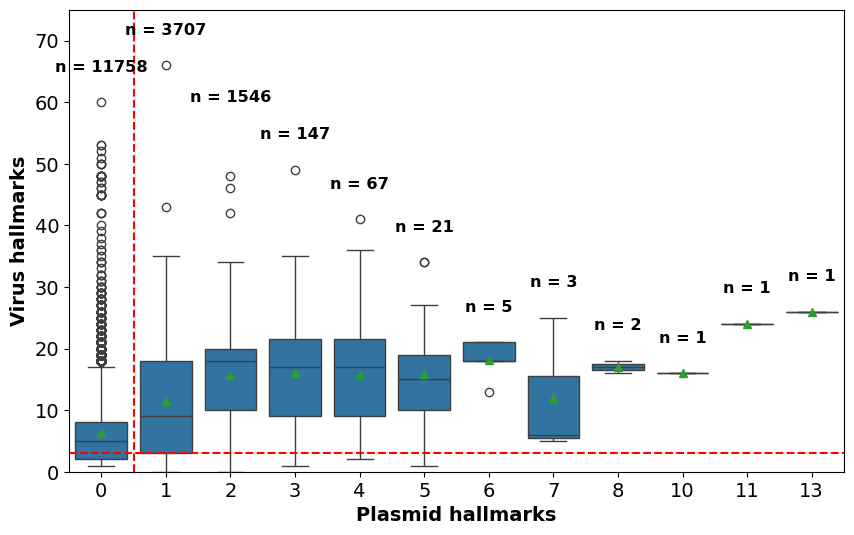

In [62]:
### summarize hallmarks per uncertain genome
uncertain_hmm_hallmarks = (
    pl.concat([
        pl.read_csv('../figure_1/uhgv_hq_hc_results/2026-03-23_outputs/hcfilter/new_hcfilter.tsv.gz', separator='\t'),
        pl.read_csv('../figure_1/uhgv_hq_lc_results/2026-03-25_outputs/hcfilter/new_hcfilter.tsv.gz', separator='\t'),
        pl.read_csv('../figure_1/uhvdb_virus_db_results/2026-03-26_outputs/hcfilter/new_hcfilter.tsv.gz', separator='\t', ignore_errors=True),
        pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/hcfilter/new_hcfilter.tsv.gz', separator='\t', ignore_errors=True)
    ])
)
# make plot wider
plt.figure(figsize=(10,6))
ax = sns.boxplot(data=uncertain_hmm_hallmarks, x="plasmid_hallmarks", y='virus_hallmarks', showmeans=True)
plt.ylabel("Virus hallmarks", fontdict={'fontweight': 'bold'})
plt.xlabel("Plasmid hallmarks", fontdict={'fontweight': 'bold'})
plt.axhline(3, color='r', linestyle='dashed')
plt.axvline(0.5, color='r', linestyle='dashed')
plt.ylim(0, 75)

maxes = uncertain_hmm_hallmarks.group_by(['plasmid_hallmarks']).agg([pl.col('virus_hallmarks').max()]).sort('plasmid_hallmarks')['virus_hallmarks']
nobs = uncertain_hmm_hallmarks['plasmid_hallmarks'].value_counts().sort('plasmid_hallmarks')['count']

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    if pos[tick] == 2:
        maxes[tick] = 55
    ax.text(pos[tick],
            maxes[tick] + 5,
            "n = " + str(nobs[tick]),
            horizontalalignment='center',
            size='small',
            color='black',
            weight='semibold')


In [ ]:
### write out genomes with >= 3 virus hallmarks and 0 plasmid hallmarks (would add 1 point to score)
uncertain2confident = (
    uncertain_hmm_hallmarks
        .filter(
            (pl.col('virus_hallmarks') >= 3) &
            (pl.col('plasmid_hallmarks') == 0)
        )
)

print("Number of sequences that would move from Uncertain to Confident:", uncertain2confident.shape[0])

uncertain2confident[['genome']].write_csv('uhvdb_hq_derep_uncertain2confident.txt', include_header=False)

Number of sequences that would move from Uncertain to Confident: 2501


In [ ]:
2501+208604

211105